In [17]:
import os
os.getcwd()


'/Users/lgm/Documents/ProjecteData/Equip_25/Data'

In [20]:
import pandas as pd

df = pd.read_csv("data_cleaning/clean_data_09-03-2026.csv")
df.columns

Index(['apartment_id', 'room_type', 'price', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'review_scores_rating', 'reviews_per_month', 'city',
       'insert_date', 'reviews 80+'],
      dtype='object')

In [23]:
import pandas as pd

df = pd.read_csv("data_cleaning/clean_data_09-03-2026.csv")

avg_rating = df["review_scores_rating"].mean()

print("Puntuación media:", round(avg_rating, 2))

Puntuación media: 91.99


In [33]:
import pandas as pd

df = pd.read_csv("data_cleaning/clean_data_09-03-2026.csv")

# 1. Puntuación media global
avg_rating = df["review_scores_rating"].mean()
print("Puntuación media global:", round(avg_rating,2))


# 2. Puntuación media por ciudad
avg_rating_city = (
    df.groupby("city")["review_scores_rating"]
      .mean()
      .sort_values(ascending=False)
).round(2)

print("\nPuntuación media por ciudad:")
print(avg_rating_city)


# 3. Puntuación media por ciudad > 80
avg_rating_city = avg_rating_city.round(2)

avg_rating_city_80 = avg_rating_city[avg_rating_city > 80]

print("\nCiudades con puntuación media > 80:")
print(avg_rating_city_80)

Puntuación media global: 91.99

Puntuación media por ciudad:
city
Sevilla      93.78
Menorca      93.37
Mallorca     93.36
Madrid       92.76
Valencia     92.44
Malaga       92.13
Girona       91.06
Barcelona    90.71
Name: review_scores_rating, dtype: float64

Ciudades con puntuación media > 80:
city
Sevilla      93.78
Menorca      93.37
Mallorca     93.36
Madrid       92.76
Valencia     92.44
Malaga       92.13
Girona       91.06
Barcelona    90.71
Name: review_scores_rating, dtype: float64


In [34]:
import pandas as pd

df = pd.read_csv("data_cleaning/clean_data_09-03-2026.csv")

# 1. Puntuación media global
avg_rating = df["review_scores_rating"].mean()
print("Puntuación media global:", round(avg_rating, 2))


# 2. Puntuación media por ciudad
avg_rating_city = (
    df.groupby("city")["review_scores_rating"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
      .to_frame(name="avg_rating")
)

print("\nPuntuación media por ciudad:")
print(avg_rating_city)


# 3. Ciudades con puntuación media > 80
avg_rating_city_80 = avg_rating_city[avg_rating_city["avg_rating"] > 80]

print("\nCiudades con puntuación media > 80:")
print(avg_rating_city_80)

Puntuación media global: 91.99

Puntuación media por ciudad:
           avg_rating
city                 
Sevilla         93.78
Menorca         93.37
Mallorca        93.36
Madrid          92.76
Valencia        92.44
Malaga          92.13
Girona          91.06
Barcelona       90.71

Ciudades con puntuación media > 80:
           avg_rating
city                 
Sevilla         93.78
Menorca         93.37
Mallorca        93.36
Madrid          92.76
Valencia        92.44
Malaga          92.13
Girona          91.06
Barcelona       90.71


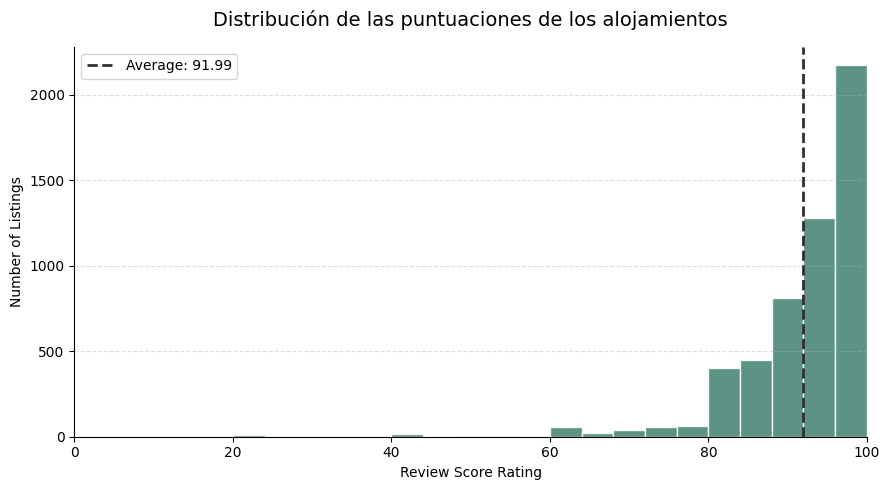

Average rating: 91.99


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_cleaning/clean_data_09-03-2026.csv")

ratings = df["review_scores_rating"].dropna()

# media
avg_rating = ratings.mean()

plt.figure(figsize=(9,5))

# histograma
plt.hist(
    ratings,
    bins=20,
    color="#3f8070",
    edgecolor="white",
    alpha=0.85
)

# línea de media
plt.axvline(
    avg_rating,
    linestyle="--",
    linewidth=2,
    color="#2f2f2f",
    label=f"Average: {avg_rating:.2f}"
)

# límites eje X
plt.xlim(0,100)

# estilo limpio
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.title("Distribución de las puntuaciones de los alojamientos", fontsize=14, pad=15)
plt.xlabel("Review Score Rating")
plt.ylabel("Number of Listings")

plt.legend()

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Average rating: {avg_rating:.2f}")

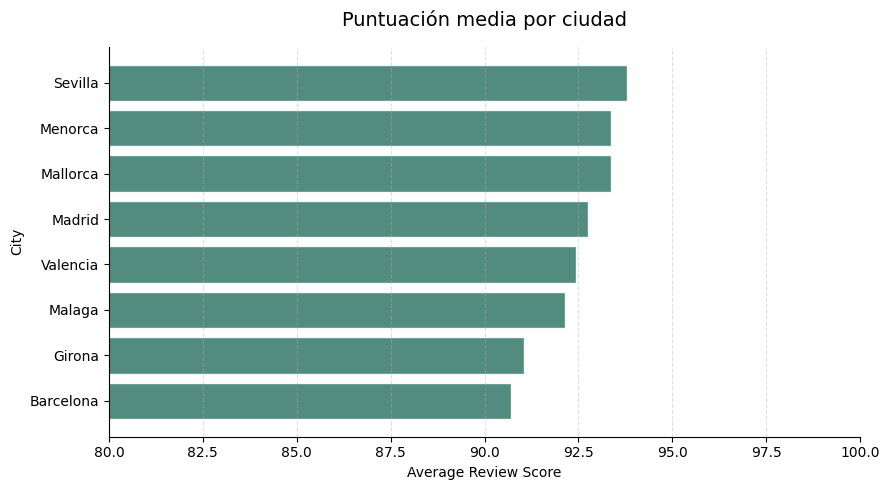

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_cleaning/clean_data_09-03-2026.csv")

# cálculo
avg_rating_city = (
    df.groupby("city")["review_scores_rating"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
      .to_frame(name="avg_rating")
)

plt.figure(figsize=(9,5))

plt.barh(
    avg_rating_city.index,
    avg_rating_city["avg_rating"],
    color="#3f8070",
    edgecolor="white",
    alpha=0.9
)

plt.gca().invert_yaxis()

plt.title("Puntuación media por ciudad", fontsize=14, pad=15)
plt.xlabel("Average Review Score")
plt.ylabel("City")

plt.grid(axis="x", linestyle="--", alpha=0.4)

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xlim(80,100)

plt.tight_layout()
plt.show()

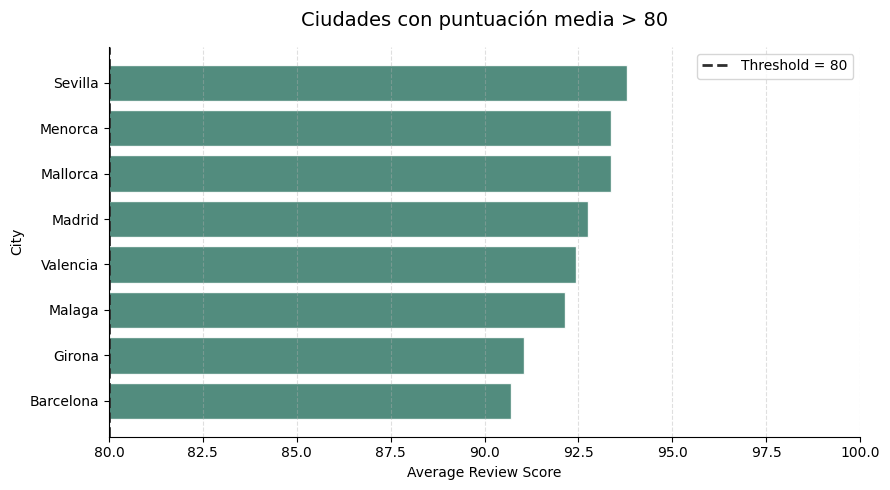

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.barh(
    avg_rating_city_80.index,
    avg_rating_city_80["avg_rating"],
    color="#3f8070",
    edgecolor="white",
    alpha=0.9
)

plt.gca().invert_yaxis()

# línea del umbral
plt.axvline(
    80,
    linestyle="--",
    linewidth=2,
    color="#2f2f2f",
    label="Threshold = 80"
)

plt.title("Ciudades con puntuación media > 80", fontsize=14, pad=15)
plt.xlabel("Average Review Score")
plt.ylabel("City")

plt.grid(axis="x", linestyle="--", alpha=0.4)

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xlim(80,100)

plt.legend()

plt.tight_layout()
plt.show()